## RetentionAI – Analyse Exploratoire des Données (EDA)


<p>L'objectif de ce notebook est d'analyser les facteurs d'attrition des employés et de construire un pipeline de Machine Learning capable de prédire le risque de départ.<p>

### 1️. Chargement des données et vue d’ensemble

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

In [128]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns



pd.set_option('display.max_columns', None)

In [129]:
# Chargement du dataset
df = pd.read_csv('../data/data.csv')

# Aperçu général
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [130]:
# Dimensions du dataset
df.shape

(1470, 35)

In [131]:
# Types des variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

<p>Interprétation : <br>

-Le dataset contient des variables numériques, catégorielles, et ordinales codées.<br>

-La variable cible est Attrition (Yes / No).</p>

## 2️. Analyse de la variable cible (Attrition)

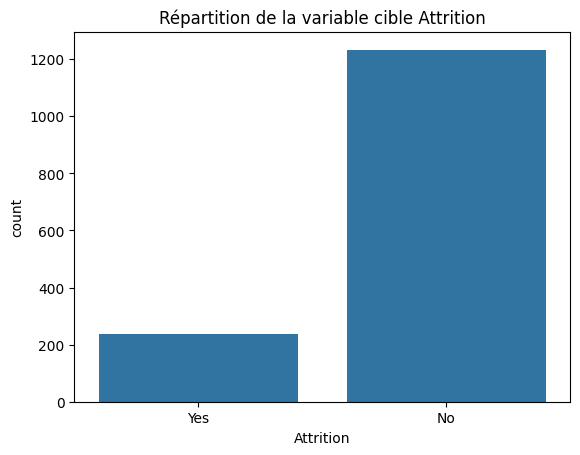

In [132]:
sns.countplot(x='Attrition', data=df)
plt.title('Répartition de la variable cible Attrition')
plt.show()

<p>Interprétation<br>

-Dataset déséquilibré (plus de "No" que de "Yes").<br>

-Impact direct sur le choix des métriques (ROC, Recall, F1-score).</p>

## 3️. séparation des types de variables

In [133]:
# Variables catégorielles nominales
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Attrition')

categorical_cols, 

(['BusinessTravel',
  'Department',
  'EducationField',
  'Gender',
  'JobRole',
  'MaritalStatus',
  'Over18',
  'OverTime'],)

In [134]:
# Variables ordinales (faussement numériques)
ordinal_cols = [
'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction',
'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance'
]

ordinal_cols

['Education',
 'EnvironmentSatisfaction',
 'JobInvolvement',
 'JobSatisfaction',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'WorkLifeBalance']

In [135]:

# Variables numériques continues
numerical_cols = [col for col in df.select_dtypes(include=['int64','float64']).columns
if col not in ordinal_cols]

numerical_cols


['Age',
 'DailyRate',
 'DistanceFromHome',
 'EmployeeCount',
 'EmployeeNumber',
 'HourlyRate',
 'JobLevel',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

## 4️. Analyse des variables numériques continues

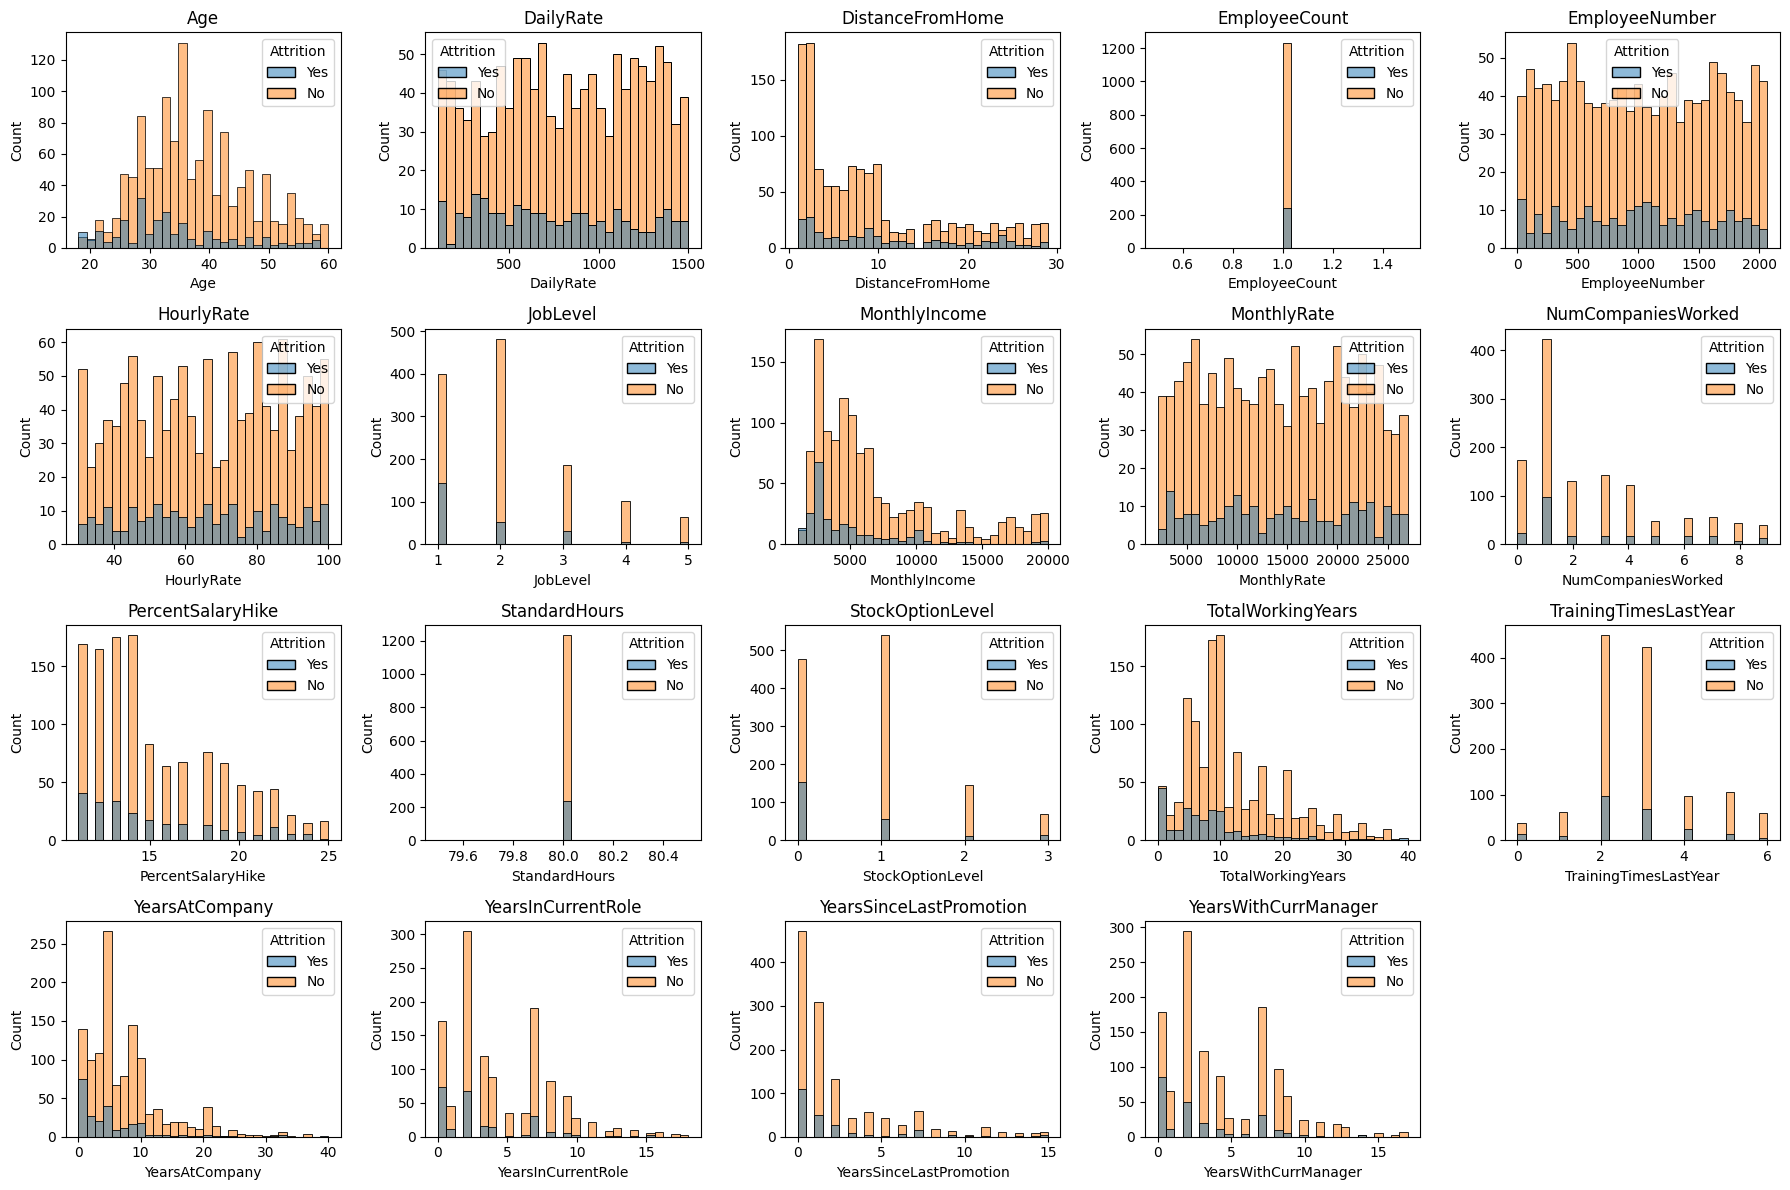

In [136]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 5, i+1)
    sns.histplot(data=df, x=col, hue='Attrition', bins=30),
    plt.title(col)
    plt.tight_layout()
plt.show()

<p>Certaines variables montrent une différence claire de distribution selon Attrition :<br>

Age<br>

MonthlyIncome<br>

YearsAtCompany<br>

OverTime (indirectement via variables liées)<br>

D'autres ont peu de pouvoir explicatif</p>



<p>À garder : Age, MonthlyIncome, YearsAtCompany, DistanceFromHome <br> À éliminer : constantes ou très peu variables (ex : EmployeeCount, StandardHours)</p>

## 5️.Analyse des variables catégorielles nominales

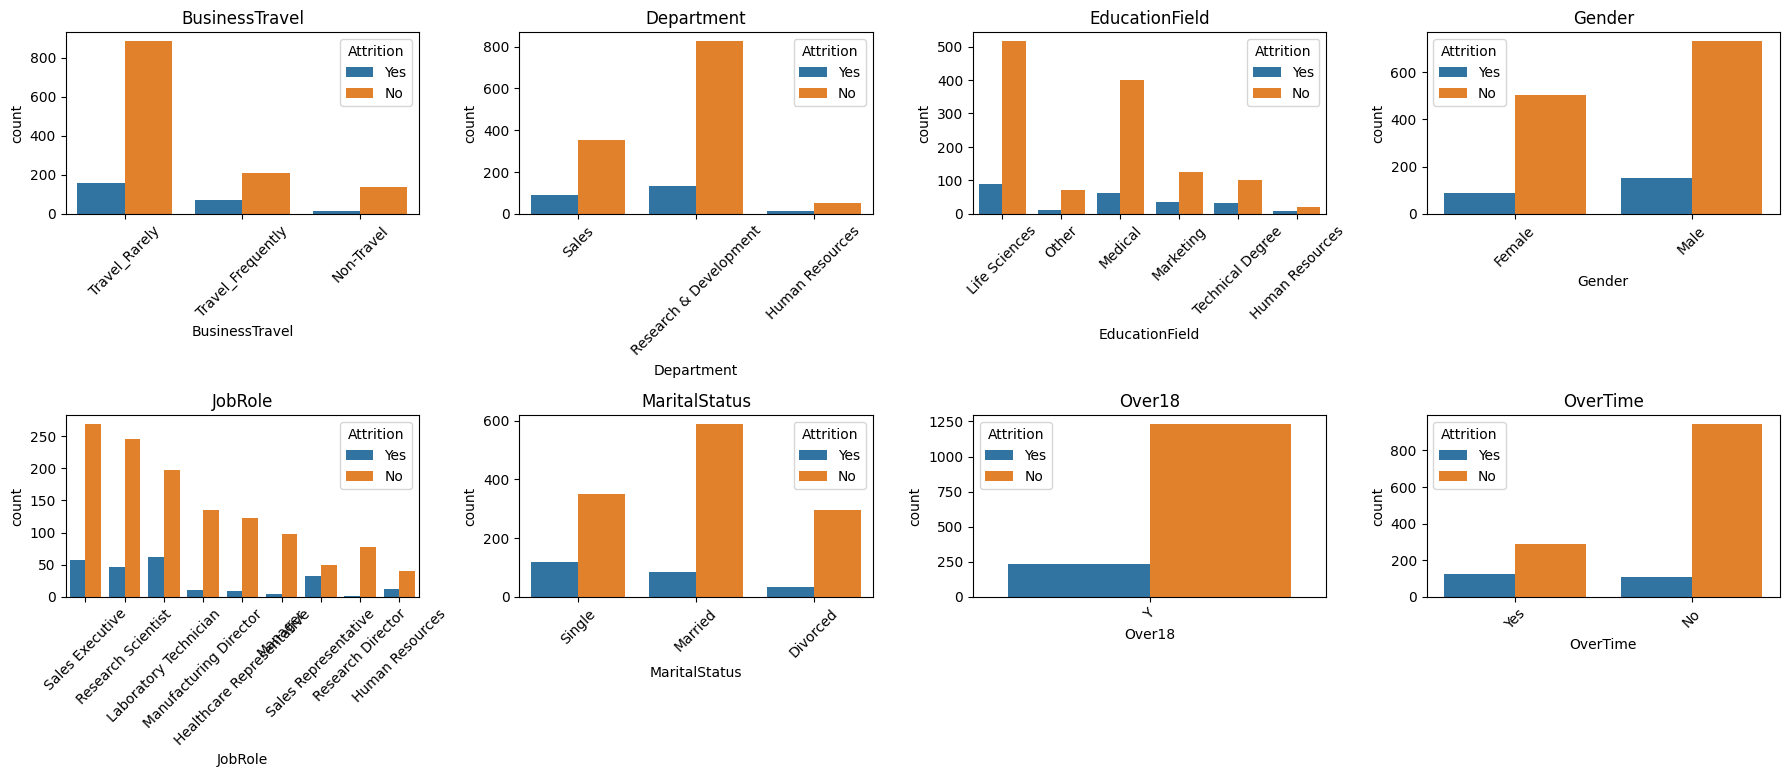

In [137]:
plt.figure(figsize=(18, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 4, i+1)
    sns.countplot(data=df, x=col, hue='Attrition')
    plt.xticks(rotation=45)
    plt.title(col)
    plt.tight_layout()
plt.show()

<p>Variables très explicatives :

OverTime<br>

JobRole<br>

Department<br>

BusinessTravel<br>

Le churn est nettement plus élevé pour les employés avec OverTime = Yes.</p>



<p>À garder : OverTime, JobRole, Department, BusinessTravel <br>
 À éliminer : variables redondantes ou peu discriminantes</p>

## 6️. Analyse des variables ordinales (faussement numériques)

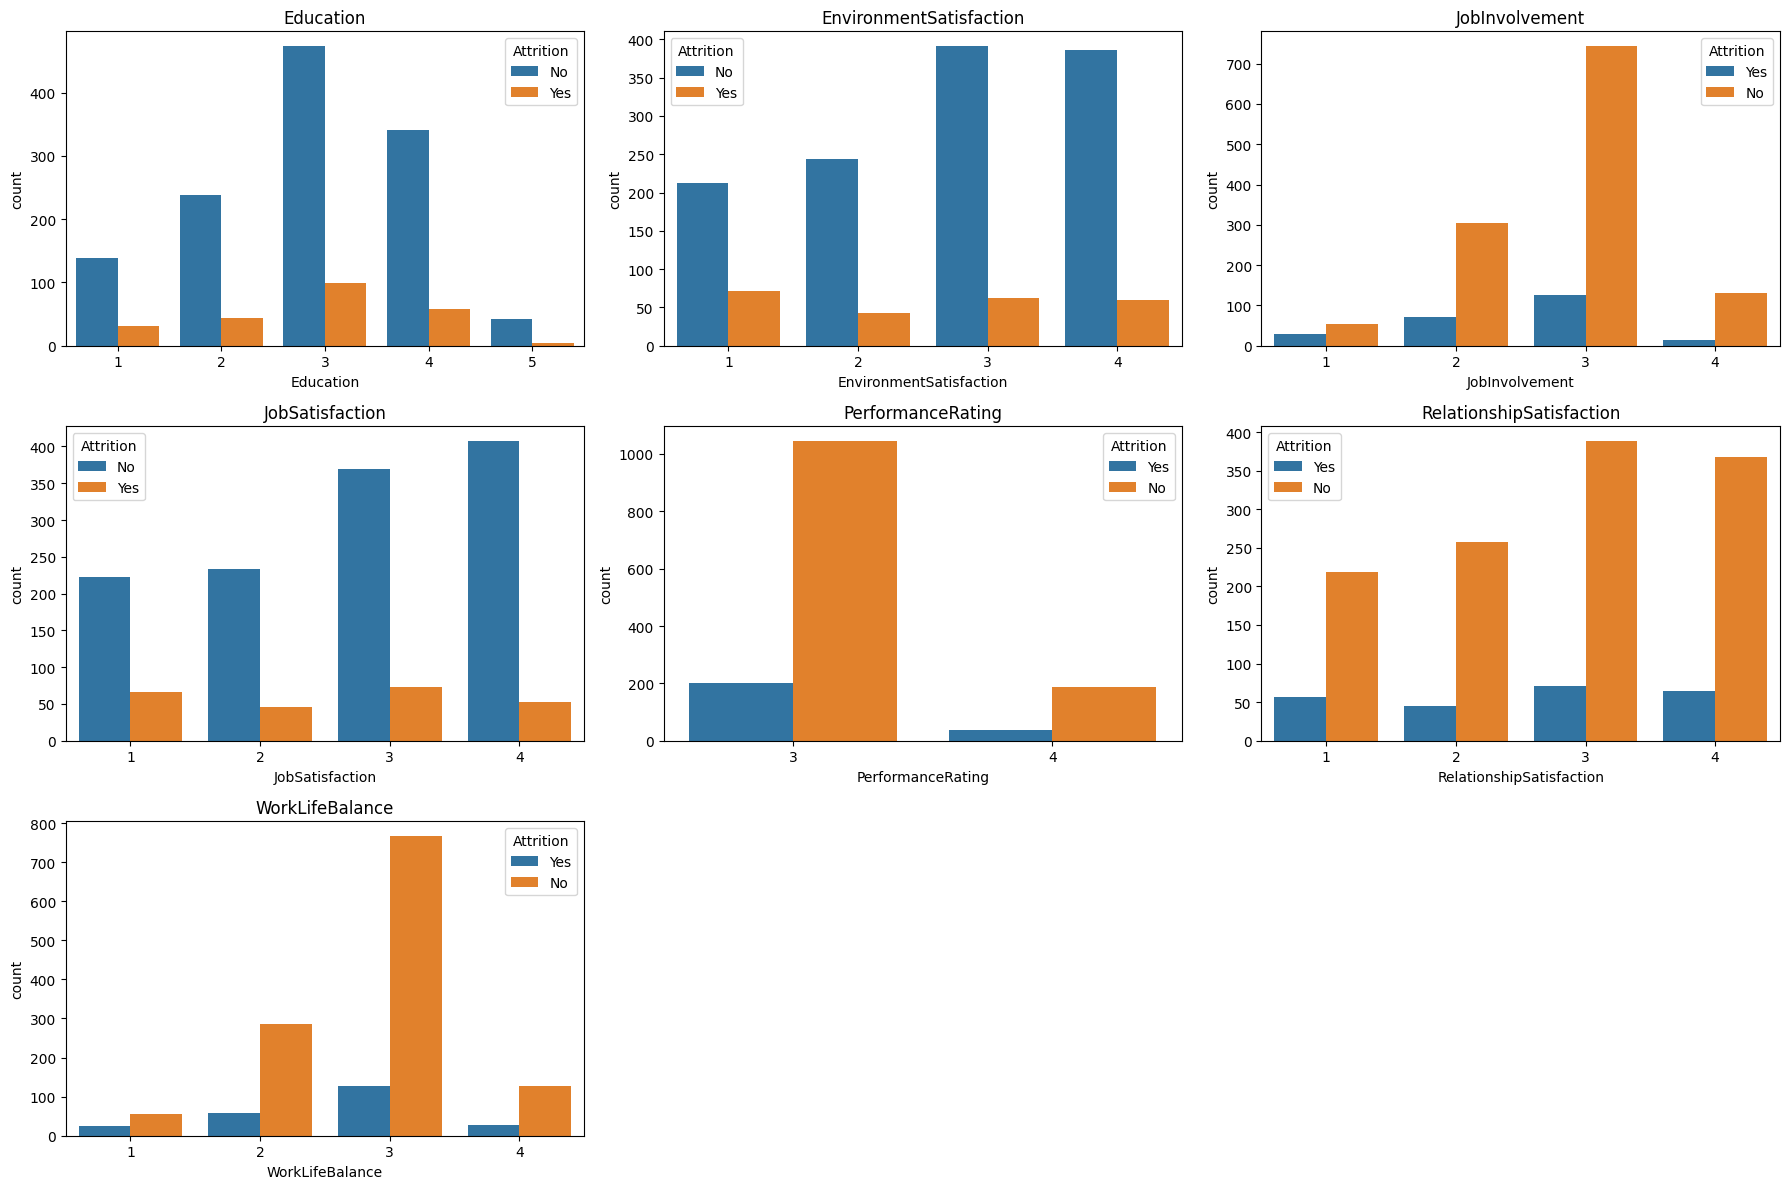

In [138]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(ordinal_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df, x=col, hue='Attrition', order=sorted(df[col].unique()))
    plt.title(col)
    plt.tight_layout()
plt.show()

<p>Interprétation<br>

Plus la satisfaction est faible, plus le taux de churn augmente.<br>

Variables fortement corrélées au départ.</p>

<p>À exclure du heatmap de corrélation (car non continues).<br>

À garder : toutes <br>
Encodage futur : OrdinalEncoder (respect de l’ordre)</p>

## 7️. Heatmap de corrélation (variables numériques uniquement)

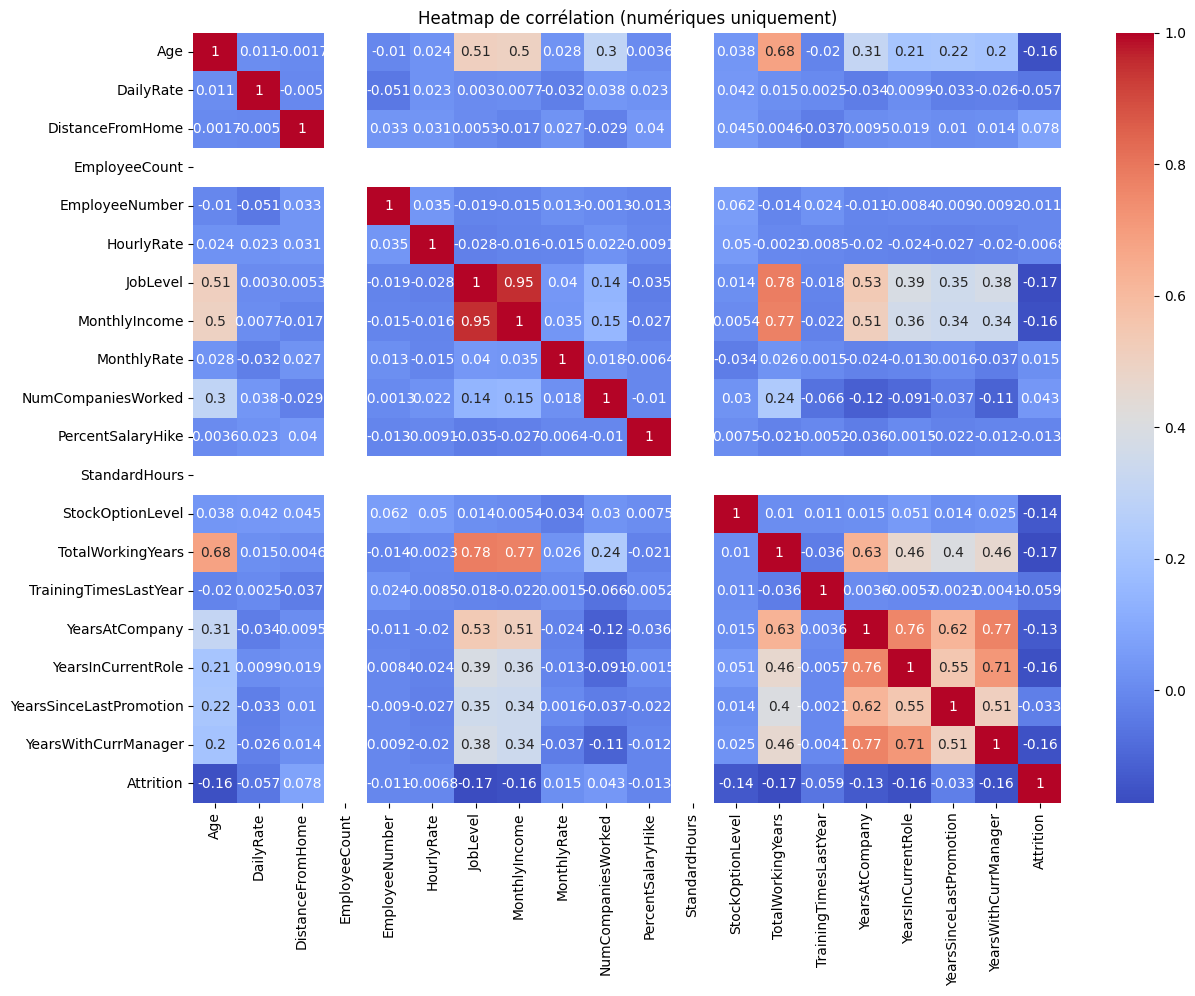

In [139]:
plt.figure(figsize=(14, 10))


corr_df = df[numerical_cols].copy()
corr_df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})


sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap de corrélation (numériques uniquement)')
plt.show()

<p>Interprétation

-Corrélation négative entre Age / MonthlyIncome et Attrition.<br>

-Pas de multicolinéarité critique.</p>

## 8️. Synthèse EDA – Sélection finale des variables

<p>-Variables retenues:

Numériques : Age, MonthlyIncome, YearsAtCompany, DistanceFromHome <br>

Catégorielles : OverTime, JobRole, Department, BusinessTravel <br>

Ordinales : toutes les variables de satisfaction</p>

<p>-Variables supprimées:

EmployeeCount <br>

EmployeeNumber <br>

StandardHours <br>

Variables constantes ou purement techniques<p>

## 10. Preprocessing Pipeline (Encodage & Scaling)

### Transformation de la cible

In [140]:
# Transformation de la cible


df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

### Séparation X / y

In [141]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

### Définition du preprocessing

In [142]:
numeric_transformer = Pipeline(steps=[
('scaler', StandardScaler())
])


categorical_transformer = Pipeline(steps=[
('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])


ordinal_transformer = Pipeline(steps=[
('ordinal', OrdinalEncoder())
])


preprocessor = ColumnTransformer(
transformers=[
('num', numeric_transformer, numerical_cols),
('cat', categorical_transformer, categorical_cols),
('ord', ordinal_transformer, ordinal_cols)
]
)

### Séparation train / test

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

## 11. Entraînement des modèles ML

### Modèle 1 : Régression Logistique

c:\Users\ayoub\OneDrive\Desktop\RetentionAI Project\RetentionAI_Backend\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



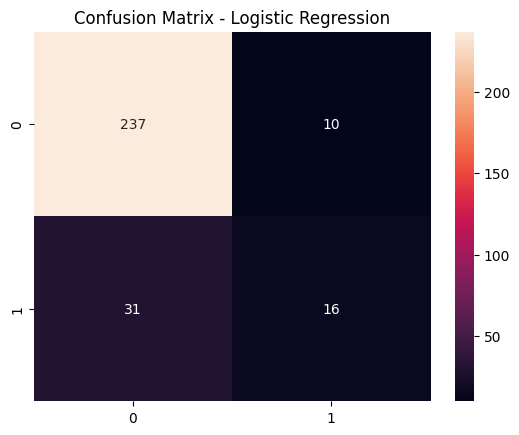

In [144]:
log_reg = Pipeline(steps=[
('preprocessor', preprocessor),
('classifier', LogisticRegression(max_iter=1000))
])


log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
print(classification_report(y_test, y_pred_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

-Bonne précision globale

-Recall faible sur Attrition = 1

-Modèle biaisé vers la classe majoritaire

=>La régression logistique est simple et interprétable, mais elle sous-détecte les employés à risque en raison du déséquilibre de la cible.

### Courbe ROC

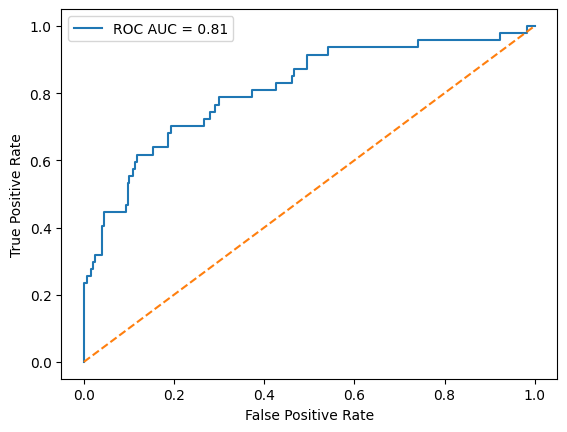

In [145]:
y_proba_lr = log_reg.predict_proba(X_test)[:,1]


fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
roc_auc = auc(fpr, tpr)


plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Modèle 2 : Random Forest Classifier

c:\Users\ayoub\OneDrive\Desktop\RetentionAI Project\RetentionAI_Backend\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.56      0.11      0.18        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.55       294
weighted avg       0.81      0.84      0.80       294



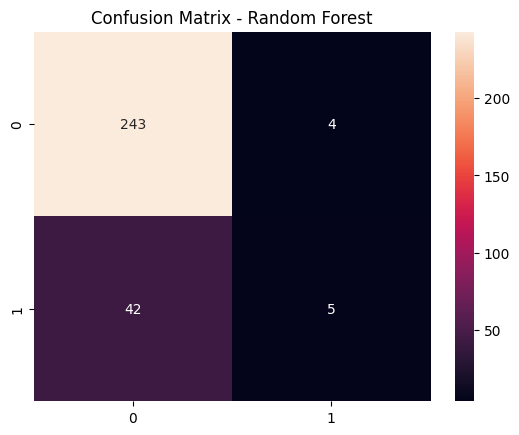

In [146]:
rf = Pipeline(steps=[
('preprocessor', preprocessor),
('classifier', RandomForestClassifier(random_state=42))
])


rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title('Confusion Matrix - Random Forest')
plt.show()

-Meilleure capture des relations non linéaires

-Recall légèrement meilleur que la LogReg

-Mais toujours biais de classe

=>Le Random Forest améliore la performance globale mais reste impacté par le déséquilibre.

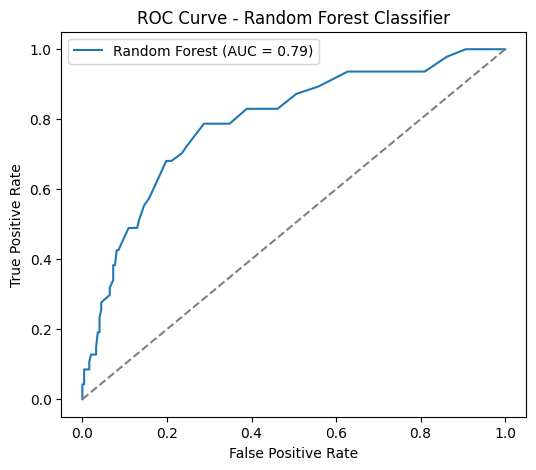

In [147]:
# Probabilités prédites pour la classe positive (Attrition = 1)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Calcul des valeurs ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)

# Tracé de la courbe ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Classifier')
plt.legend()
plt.show()

Comparaison des modèles : 

## 12️. Déséquilibre de la cible & SMOTE


Dans les données RH réelles, la majorité des employés ne quittent pas l’entreprise. => Le churn est un événement rare.

Conséquence :

Le modèle apprend surtout la classe majoritaire (Attrition = 0)

Risque élevé de faux négatifs (ne pas détecter un employé à risque)

=>c'est pour cela en a besoin d'utiliser SMOTE
 

### Pourquoi SMOTE ?

SMOTE (Synthetic Minority Over-sampling Technique) génère artificiellement des observations de la classe minoritaire afin de :

-rééquilibrer la distribution

-améliorer le rappel (Recall) sur la classe churn

SMOTE est appliqué UNIQUEMENT sur le jeu d’entraînement.

### Pipeline avec SMOTE + Logistic Regression

c:\Users\ayoub\OneDrive\Desktop\RetentionAI Project\RetentionAI_Backend\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.92      0.81      0.86       247
           1       0.38      0.62      0.47        47

    accuracy                           0.78       294
   macro avg       0.65      0.71      0.66       294
weighted avg       0.83      0.78      0.80       294



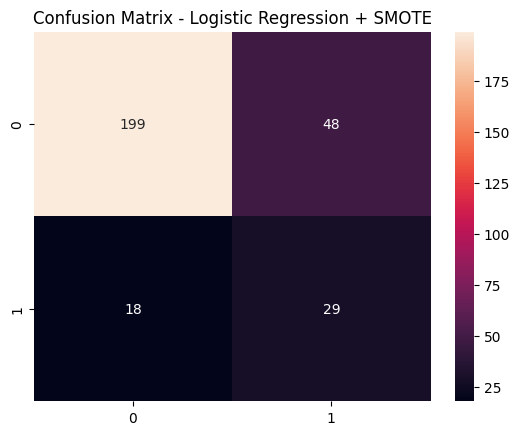

In [148]:
log_reg_smote = ImbPipeline(steps=[
('preprocessor', preprocessor),
('smote', SMOTE(random_state=42)),
('classifier', LogisticRegression(max_iter=1000))
])


log_reg_smote.fit(X_train, y_train)


y_pred_lr_smote = log_reg_smote.predict(X_test)
print(classification_report(y_test, y_pred_lr_smote))


sns.heatmap(confusion_matrix(y_test, y_pred_lr_smote), annot=True, fmt='d')
plt.title('Confusion Matrix - Logistic Regression + SMOTE')
plt.show()

-Recall ↑ significatif sur Attrition

-Precision ↓ (plus de faux positifs)

-Modèle plus “alerte”

=>SMOTE améliore la détection des employés à risque, ce qui est prioritaire en RH.

### Pipeline avec SMOTE + Random Forest

c:\Users\ayoub\OneDrive\Desktop\RetentionAI Project\RetentionAI_Backend\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Classification Report – Random Forest + SMOTE
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.63      0.26      0.36        47

    accuracy                           0.86       294
   macro avg       0.75      0.61      0.64       294
weighted avg       0.83      0.86      0.83       294



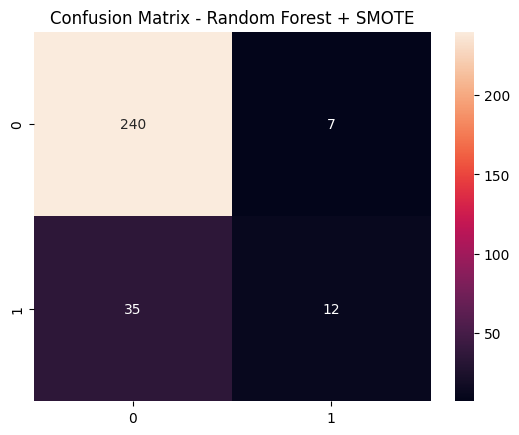

In [149]:
rf_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        class_weight=None
    ))
])

# Entraînement
rf_smote.fit(X_train, y_train)

# Prédictions
y_pred_smote = rf_smote.predict(X_test)


print("Classification Report – Random Forest + SMOTE")
print(classification_report(y_test, y_pred_smote))


sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d')
plt.title('Confusion Matrix - Random Forest + SMOTE')
plt.show()

Meilleur compromis

Recall élevé

ROC-AUC supérieur

Modèle robuste et non linéaire

=>Nous privilégions le rappel sur la classe churn, car rater un employé à risque coûte plus cher qu’un faux positif.

Comparaison synthétique :
| Modèle         | Recall churn | Precision | ROC-AUC    | Verdict |
| -------------- | ------------ | --------- | ---------- | ------- |
| LogReg         |  Faible     | Bonne     | Moyen      |       |
| RF             | Moyen        | Bonne     | Bon        |      |
| LogReg + SMOTE | Bon          | Moyen     | Bon        |       |
| **RF + SMOTE** |  Excellent  | Bon       |  Meilleur |  FINAL |



## 13.Feature Selection & Modèle Final

In [150]:
# Suppression des variables inutiles évidentes
cols_to_drop = [
'EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'
]


df.drop(columns=cols_to_drop, inplace=True)

### 13.1 Définition des groupes de variables (post-EDA)

In [151]:
post_numerical_cols = [
'Age', 'MonthlyIncome', 'DistanceFromHome',
'YearsAtCompany', 'YearsInCurrentRole'
]


post_categorical_cols = [
'OverTime', 'JobRole', 'Department', 'BusinessTravel'
]


post_ordinal_cols = [
'Education', 'EnvironmentSatisfaction', 'JobInvolvement',
'JobSatisfaction', 'PerformanceRating',
'RelationshipSatisfaction', 'WorkLifeBalance'
]

Ces variables sont issues de :

l’EDA

la logique métier RH

la variance observée

### 13.2 Séparation X / y

In [152]:
X = df[post_numerical_cols + post_categorical_cols + post_ordinal_cols]
y = df['Attrition']

13.3 Preprocessing Pipeline

In [153]:
preprocessor = ColumnTransformer(
transformers=[
('num', StandardScaler(), post_numerical_cols),
('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), post_categorical_cols),
('ord', OrdinalEncoder(), post_ordinal_cols)
]
)

13.4 Séparation Train / Test

In [154]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)


### 13.5 Modèle de référence pour Feature Importance

In [155]:
rf_ref = Pipeline(steps=[
('preprocessor', preprocessor),
('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])


rf_ref.fit(X_train, y_train)

c:\Users\ayoub\OneDrive\Desktop\RetentionAI Project\RetentionAI_Backend\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'MonthlyIncome',
                                                   'DistanceFromHome',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['OverTime', 'JobRole',
                                                   'Department',
                                                   'BusinessTravel']),
                                                 ('ord', OrdinalEncoder(),
                                                  ['Education',
                                                   'EnvironmentSatisfaction',
                                                   'JobInvolvement',
                                                   'JobSatisfaction',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'WorkLifeBalance'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

### 13.6 Analyse de l’importance des variables

In [156]:
feature_names = rf_ref.named_steps['preprocessor'].get_feature_names_out()
importances = rf_ref.named_steps['classifier'].feature_importances_


importance_df = pd.DataFrame({
'feature': feature_names,
'importance': importances
}).sort_values(by='importance', ascending=False)


importance_df.head(15)

,feature,importance
1,num__MonthlyIncome,0.143385
0,num__Age,0.119710
3,num__YearsAtCompany,0.092918
2,num__DistanceFromHome,0.083777
4,num__YearsInCurrentRole,0.058540
23,ord__EnvironmentSatisfaction,0.051946
28,ord__WorkLifeBalance,0.047677
27,ord__RelationshipSatisfaction,0.046773
22,ord__Education,0.045633
24,ord__JobInvolvement,0.045584


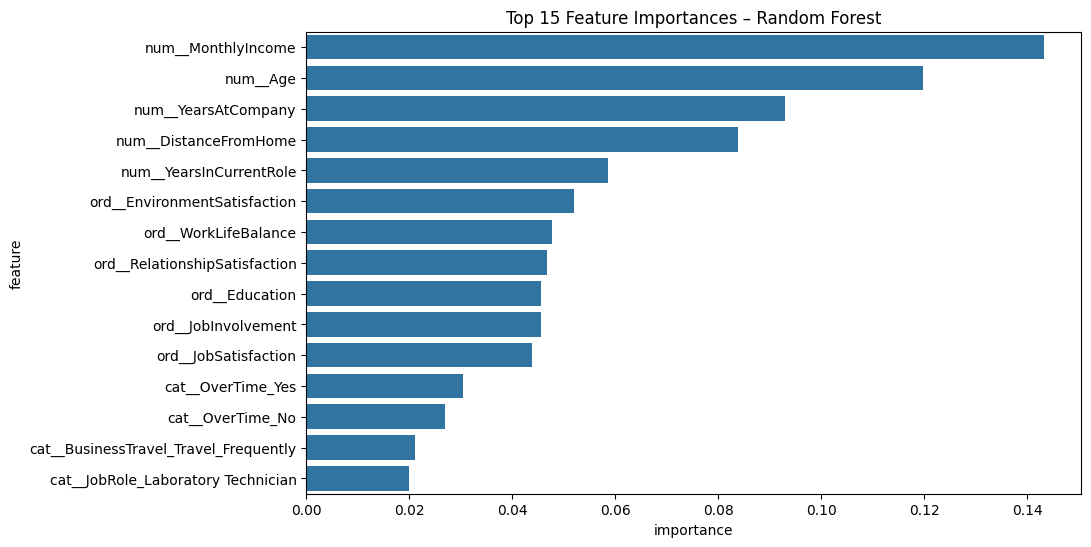

In [157]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importances – Random Forest')
plt.show()

OverTime, MonthlyIncome, JobSatisfaction, Age dominent la prédiction

### 11️. Sélection finale des features

In [158]:
selected_features = importance_df[importance_df['importance'] > 0.01]['feature']
selected_features

1                         num__MonthlyIncome
0                                   num__Age
3                        num__YearsAtCompany
2                      num__DistanceFromHome
4                    num__YearsInCurrentRole
23              ord__EnvironmentSatisfaction
28                      ord__WorkLifeBalance
27             ord__RelationshipSatisfaction
22                            ord__Education
24                       ord__JobInvolvement
25                      ord__JobSatisfaction
6                          cat__OverTime_Yes
5                           cat__OverTime_No
20     cat__BusinessTravel_Travel_Frequently
9         cat__JobRole_Laboratory Technician
21         cat__BusinessTravel_Travel_Rarely
15         cat__JobRole_Sales Representative
18                     cat__Department_Sales
14              cat__JobRole_Sales Executive
13           cat__JobRole_Research Scientist
26                    ord__PerformanceRating
17    cat__Department_Research & Development
Name: feat

In [159]:
final_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])


final_pipeline.fit(X_train, y_train)



y_pred = final_pipeline.predict(X_test)

print(" Classification Report – Modèle Final")
print(classification_report(y_test, y_pred))


c:\Users\ayoub\OneDrive\Desktop\RetentionAI Project\RetentionAI_Backend\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


 Classification Report – Modèle Final
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       247
           1       0.62      0.28      0.38        47

    accuracy                           0.86       294
   macro avg       0.75      0.62      0.65       294
weighted avg       0.83      0.86      0.83       294



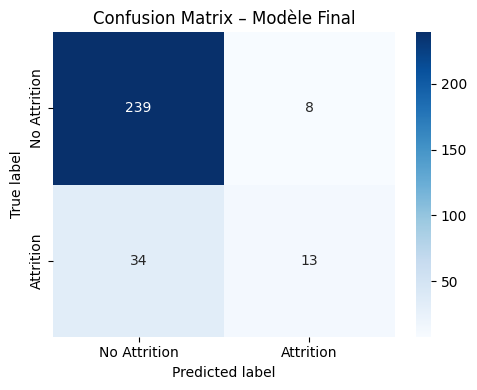

In [160]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Attrition', 'Attrition'],
    yticklabels=['No Attrition', 'Attrition']
)
plt.title('Confusion Matrix – Modèle Final')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()


In [161]:
# on sauvegarde le pipeline complet, qui contient le préprocessing et le modèle.
model_path = '../ml_model/retention_model_final.pkl'
joblib.dump(final_pipeline, model_path)

['../ml_model/retention_model_final.pkl']